In [1]:
# core stuff
import pickle as pk
import numpy as np
import sys
sys.path.append('../')
import eclipsenets as en
from scipy.spatial.distance import cdist

# meshing
import pyvista as pv
import tetgen

# plotting stuff
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

#now shapely & scipy for eclipse function calculation:
import shapely
from shapely.geometry import Polygon, Point
from scipy.spatial.distance import cdist

%load_ext autoreload
%autoreload 2

In [2]:
#with open("3dmeshes/Eros_raw.pk", "rb") as f:
#with open("3dmeshes/Bennu_raw.pk", "rb") as f:
with open("../3dmeshes/Churyumov-Gerasimenko_raw.pk", "rb") as f:
#with open("3dmeshes/Itokawa_raw.pk", "rb") as f:
    mesh_points, mesh_triangles = pk.load(f)
mesh_points = np.array(mesh_points)
mesh_triangles = np.array(mesh_triangles)

#with open("3dmeshes/Eros_raw_lp.pk", "rb") as f:
#with open("3dmeshes/Bennu_raw_lp.pk", "rb") as f:
with open("../3dmeshes/Churyumov-Gerasimenko_raw_lp.pk", "rb") as f:
#with open("3dmeshes/Itokawa_raw_lp.pk", "rb") as f:
    mesh_points_lp, mesh_triangles_lp = pk.load(f)
mesh_points_lp = np.array(mesh_points_lp)
mesh_triangles_lp = mesh_triangles
# Characteristic dimension (To know the units of the model, e.g. Eros is in km)
L = max(mesh_points[:,0]) - min(mesh_points[:,0])
#print("Characteristic dimension (Eros):", L, "Km")
#print("Characteristic dimension (Bennu):", L, "Km")
#print("Characteristic dimension (Churyumov-Gerasimenko):", L, "m")
print("Characteristic dimension (Itokawa):", L, "km")
mesh_points = mesh_points / L
mesh_points_lp = mesh_points_lp / L


Characteristic dimension (Itokawa): 5002.5703125 km


In [3]:
max_value,min_value=mesh_points.max()+abs(mesh_points.max())/4,mesh_points.min()-abs(mesh_points.min())/4
print(max_value,min_value)

0.6245466807883135 -0.6254533192116865


In [4]:
def cartesian_to_spherical(x, y, z):
    # Calculate azimuth (in degrees)
    azimuth = np.degrees(np.arctan2(y, x))
    # Calculate elevation (in degrees)
    elevation = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
    return azimuth, elevation

## Find Border

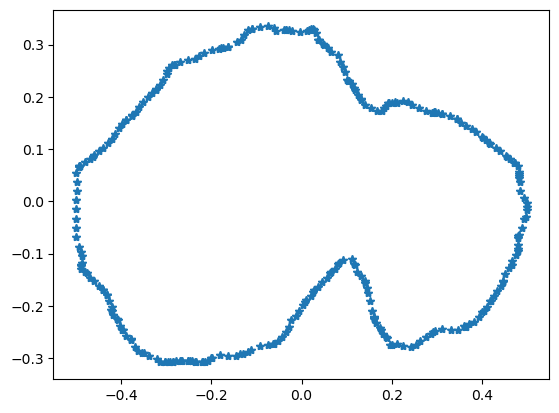

In [5]:
xyz_dir,_,_=en.fibonacci_sphere(10)
twod_points=np.stack(en.project_on_plane(mesh_points, xyz_dir[-1,:])).T
dic_alpha=en.alpha_shape(twod_points, alpha=0.013)#for Eros --> 0.02, for bennu --> 0.019, for Chu-Ger --> 0.015
border_indices=list(dic_alpha)
border_indices=np.array(border_indices).flatten()
border_points=twod_points[border_indices]
plt.plot(border_points[:,0],border_points[:,1],'*')


## Sample around border

Given the border above, the objective is to generate MC samples around each border point, with a given radius R

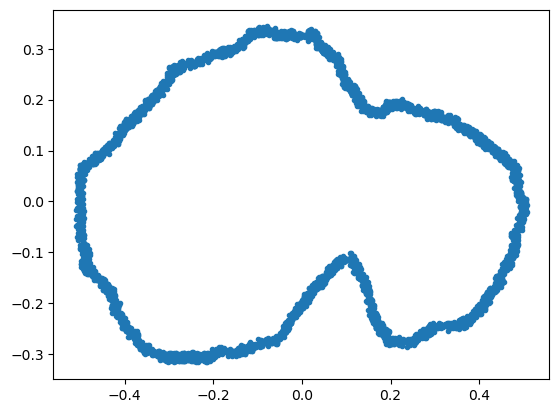

In [6]:
samples=en.sample_points(border_points, r=.01, num_samples_per_point=10)#with Eros --> r=1, with Bennu #r=0.05, with Chu-Ger r=0.05, with itokawa r=0.05
plt.plot(samples[:,0],samples[:,1],'.')

## Construct function that is zero at the border

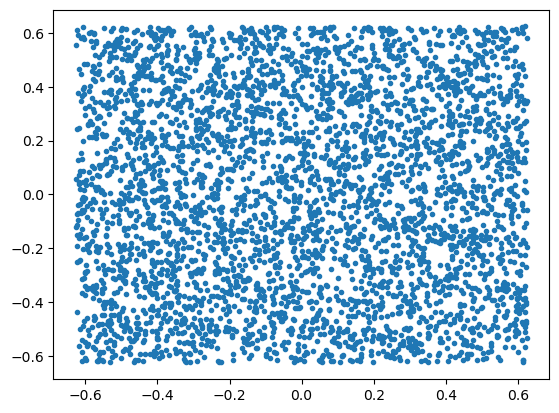

In [7]:
#let's generate random points in a square:
num_points=4000
random_points=np.random.uniform(min_value,max_value,(num_points,2))
plt.plot(random_points[:,0],random_points[:,1],'.')

In [8]:
#now based on the border we computed, let's compute wheather each of these is inside or outside:
sorted_points=np.array(en.nearest_neighbor(border_points))
surface=Polygon(sorted_points)

In [9]:
bool_list=[surface.contains(shapely.geometry.Point(val[0],val[1])) for val in random_points]

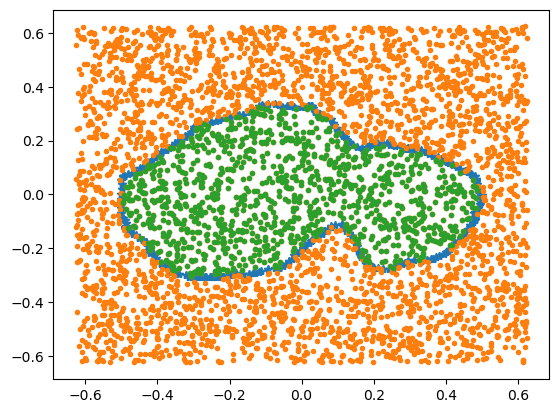

In [10]:
plt.plot(border_points[:,0],border_points[:,1],'*')
#v=np.array(sort_points_along_boundary(border_points))
#plt.plot(v[-10:,0],v[-10:,-1],'*')
plt.plot(random_points[:,0],random_points[:,1],'.',alpha=1)
plt.plot(random_points[bool_list,0],random_points[bool_list,1],'.')
#plt.xlim([-13,10])
#plt.ylim([-10,13])

## Eclipse function

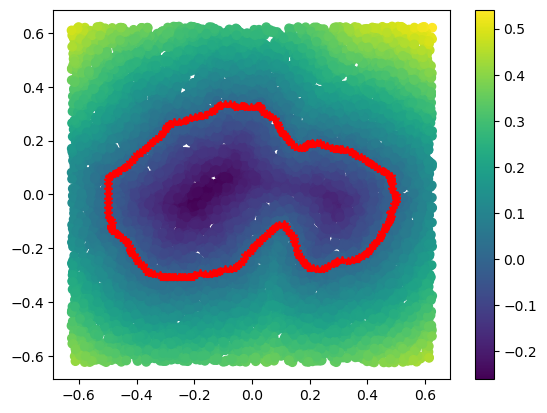

In [11]:
#let's generate random points in a square:
num_points=10000
random_points=np.random.uniform(min_value,max_value,(num_points,2))
#let's compute the shadow of the asteroid:
sorted_points=np.array(en.nearest_neighbor(border_points))
surface=Polygon(sorted_points)
#now let's all the random points using the min_distances as colorbar
min_distances_bool=en.compute_eclipse_function(random_points,border_points, surface=surface)
plt.scatter(random_points[:,0],random_points[:,1],c=min_distances_bool)
plt.colorbar()
#let's add the zero level curve
plt.plot(border_points[:,0],border_points[:,1],'r*')

what if we add extra samples only around the border?

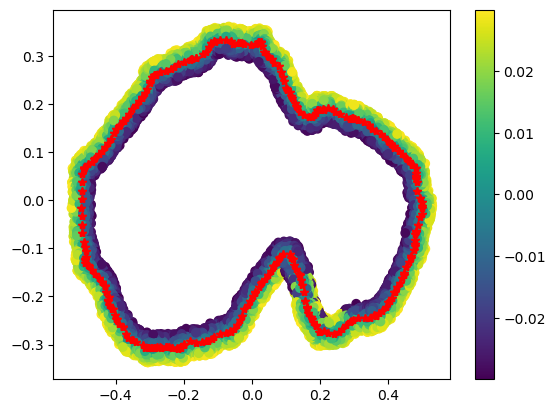

In [12]:
samples=en.sample_points(border_points, r=.03, num_samples_per_point=50)
#merge these samples with the random points above:
#samples=np.vstack([samples,random_points])
#plt.plot(samples[:,0],samples[:,1],'.')
sorted_points=np.array(en.sort_points_along_boundary(border_points))
surface=Polygon(sorted_points)
#now let's all the random points using the min_distances as colorbar
min_distances_bool=en.compute_eclipse_function(samples,border_points, surface=surface)
plt.scatter(samples[:,0],samples[:,1],c=min_distances_bool)
plt.colorbar()
#let's add the zero level curve
plt.plot(border_points[:,0],border_points[:,1],'r*')

## db generation

* Step 1: generate points of view (using Fibonacci sphere)
* Step 2: add extra samples only around the border
* Step 3: for each point of view, generate the points on the plane, and label them
* Step 4: repeat 1,2,3,4 until end

In [ ]:
from tqdm import tqdm
n_fow=500
n_random_points=1000
n_samples_per_point=10
xyz_dir,az,el=en.fibonacci_sphere(n_fow)

#let's loop over the points:
db=[]
for i in tqdm(range(n_fow)):
    #I extract the silhouette of the shadow points for each point of view:
    twod_points=np.stack(en.project_on_plane(mesh_points,xyz_dir[i])).T#en.project_to_2d(mesh_points,xyz_dir[i])
    dic_alpha=en.alpha_shape(twod_points, alpha=0.0132)#0.03 for Eros
    border_indices=list(dic_alpha)
    border_indices=np.array(border_indices).flatten()
    border_points=twod_points[border_indices]
    #I then sort them along the curve:
    sorted_points=np.stack(en.nearest_neighbor(border_points))
    #and construct the surface:
    surface=Polygon(sorted_points)
    max_value,min_value=border_points.max()+abs(border_points.max())/4,border_points.min()-abs(border_points.min())/4

    #we generate points along the border
    rand_indices=np.random.choice(range(len(border_points)),size=300,replace=False)
    corner_samples=en.sample_points(border_points[rand_indices], r=.009, num_samples_per_point=n_samples_per_point)
    #as well as random ones:
    random_points=np.random.uniform(min_value, max_value,(n_random_points,2))
    #let's stack them:
    samples=np.vstack([corner_samples,random_points,border_points])
    #let's store the min_distances:
    min_distances=en.compute_eclipse_function(samples, border_points, surface=surface)
    repeat_len=len(samples)
    db_in=np.zeros((repeat_len,7))
    db_in[:,0]=np.repeat(np.cos(az[i]),repeat_len)
    db_in[:,1]=np.repeat(np.sin(az[i]),repeat_len)
    db_in[:,2]=np.repeat(np.cos(el[i]),repeat_len)
    db_in[:,3]=np.repeat(np.sin(el[i]),repeat_len)
    db_in[:,4]=samples[:,0]
    db_in[:,5]=samples[:,1]
    db_in[:,6]=min_distances
    db.append(db_in)
    
    bool_list=[surface.contains(shapely.geometry.Point(val[0],val[1])) for val in samples]

db=np.vstack(db)
with open(f"datasets/chu-ger_db_{len(db)}_L={L}_lp.pk", "wb") as file:
    pk.dump(db, file)